In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

raw_data = pd.read_csv(
    '/content/drive/Shareddrives/Data Club - BoozAllen Spring 2026/Datasets/Raw Full Data/raw_main_data.csv'
)

raw_data.head()

,text,label
0,Hi\n\n\t\tI am running the IR test program fro...,human_legit
1,\n\n\n\n\n\n\n\n\n\n\n\n\nSecurity Note: Trade...,human_legit
2,\n\n\n\n\n\n\n\n\n\nTrade Me Offer RequestGene...,human_legit
3,"Hi Tony\nNot sure why it didn't work, but I ma...",human_legit
4,Kindly suggest changes\n\n--------------------...,human_legit


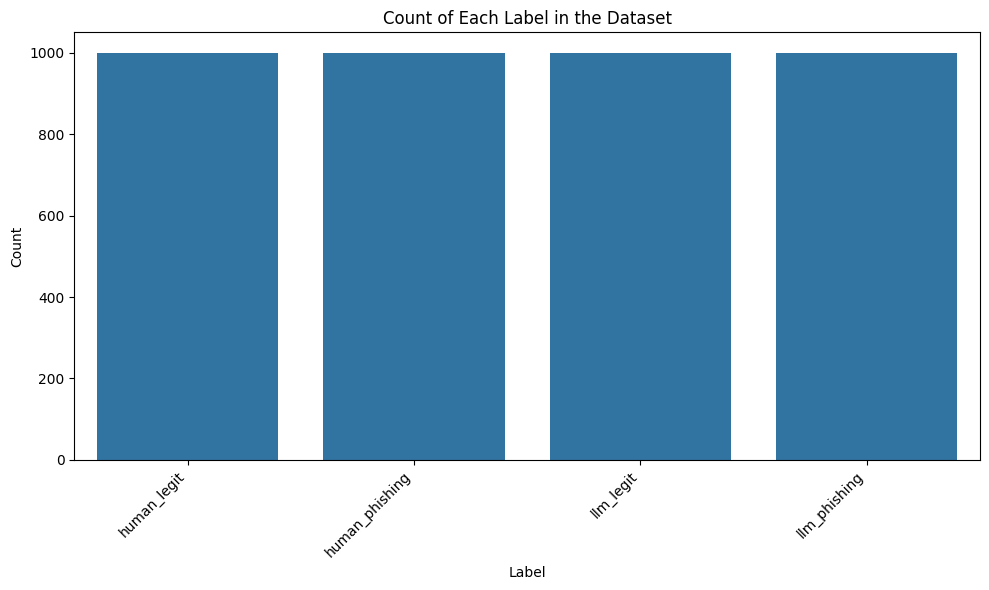

In [18]:
label_counts = raw_data['label'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Count of Each Label in the Dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
raw_data['text_length'] = raw_data['text'].str.len()
raw_data.head()

,text,label,text_length
0,Hi\n\n\t\tI am running the IR test program fro...,human_legit,193.0
1,\n\n\n\n\n\n\n\n\n\n\n\n\nSecurity Note: Trade...,human_legit,698.0
2,\n\n\n\n\n\n\n\n\n\nTrade Me Offer RequestGene...,human_legit,308.0
3,"Hi Tony\nNot sure why it didn't work, but I ma...",human_legit,3171.0
4,Kindly suggest changes\n\n--------------------...,human_legit,194.0


In [20]:
overall_avg_length = raw_data['text_length'].mean()
avg_length_per_label = raw_data.groupby('label')['text_length'].mean()

print(f"Overall Average Email Length: {overall_avg_length:.2f}")
print("\nAverage Email Length per Label Type:")
print(avg_length_per_label)

Overall Average Email Length: 1478.22

Average Email Length per Label Type:
label
human_legit       3496.985887
human_phishing    1139.952000
llm_legit          642.922000
llm_phishing       649.167000
Name: text_length, dtype: float64


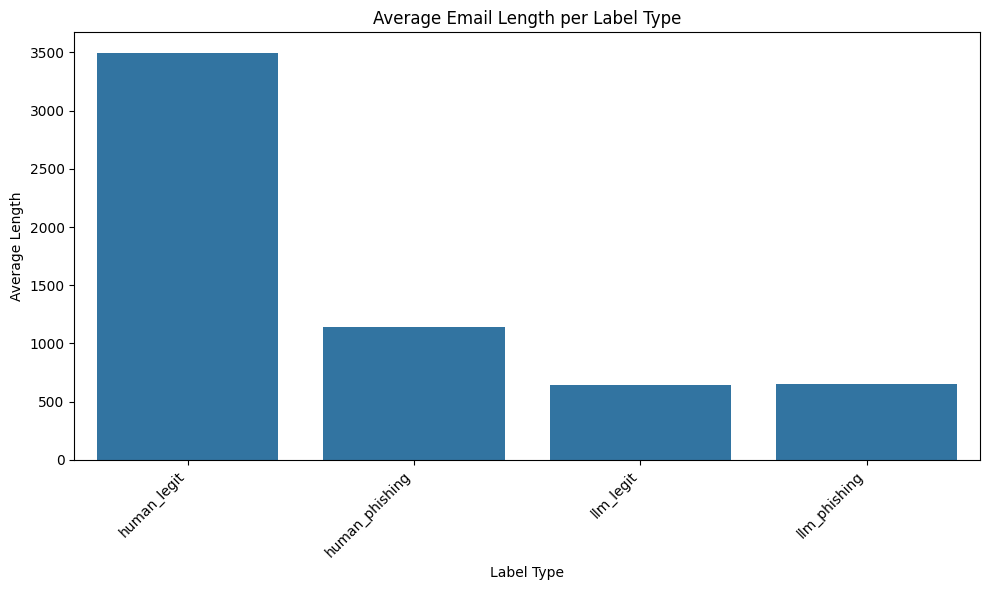

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_length_per_label.index, y=avg_length_per_label.values)
plt.title('Average Email Length per Label Type')
plt.xlabel('Label Type')
plt.ylabel('Average Length')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
bins = [0, 500, 1000, 2000, 4000, float('inf')]
labels = ['Very Short', 'Short', 'Medium', 'Long', 'Very Long']

raw_data['length_category'] = pd.cut(raw_data['text_length'], bins=bins, labels=labels, right=False)
raw_data.head()

,text,label,text_length,length_category
0,Hi\n\n\t\tI am running the IR test program fro...,human_legit,193.0,Very Short
1,\n\n\n\n\n\n\n\n\n\n\n\n\nSecurity Note: Trade...,human_legit,698.0,Short
2,\n\n\n\n\n\n\n\n\n\nTrade Me Offer RequestGene...,human_legit,308.0,Very Short
3,"Hi Tony\nNot sure why it didn't work, but I ma...",human_legit,3171.0,Long
4,Kindly suggest changes\n\n--------------------...,human_legit,194.0,Very Short


In [23]:
length_category_proportions = raw_data['length_category'].value_counts(normalize=True)
print(length_category_proportions)

length_category
Short         0.445140
Very Short    0.282315
Medium        0.157315
Very Long     0.058868
Long          0.056363
Name: proportion, dtype: float64


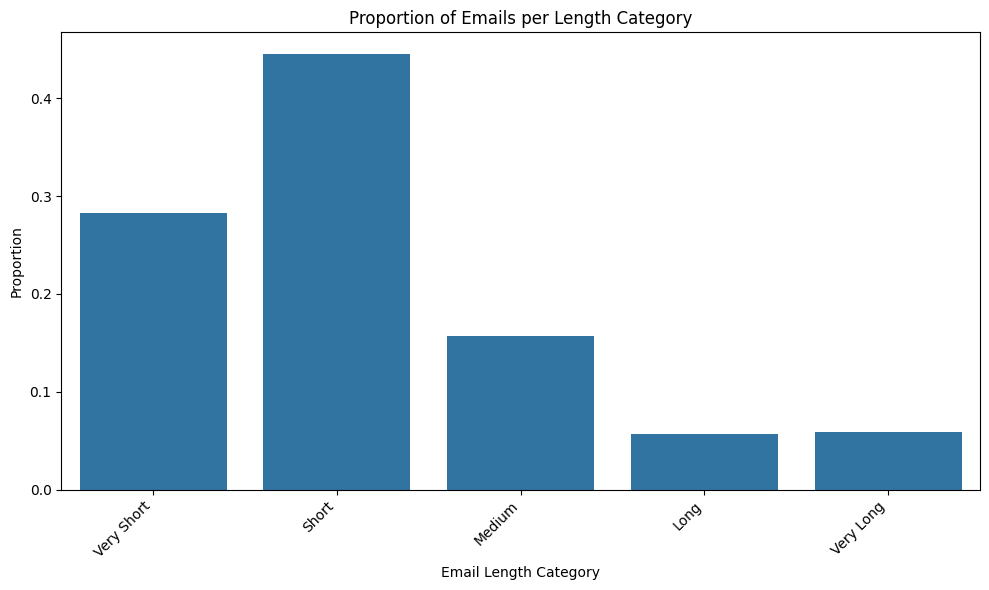

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x=length_category_proportions.index, y=length_category_proportions.values)
plt.title('Proportion of Emails per Length Category')
plt.xlabel('Email Length Category')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

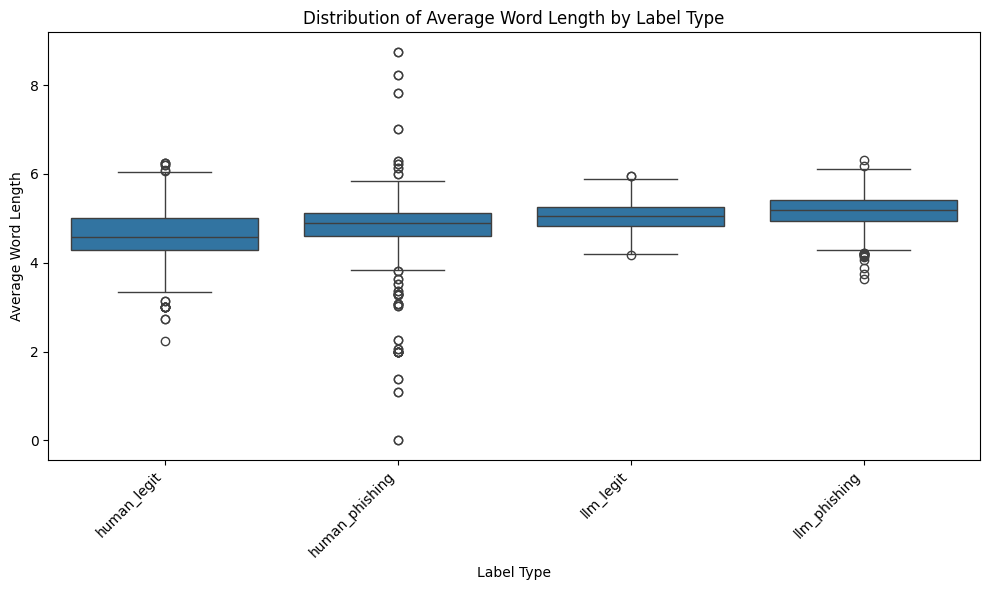

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='average_word_length', data=raw_data)
plt.title('Distribution of Average Word Length by Label Type')
plt.xlabel('Label Type')
plt.ylabel('Average Word Length')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

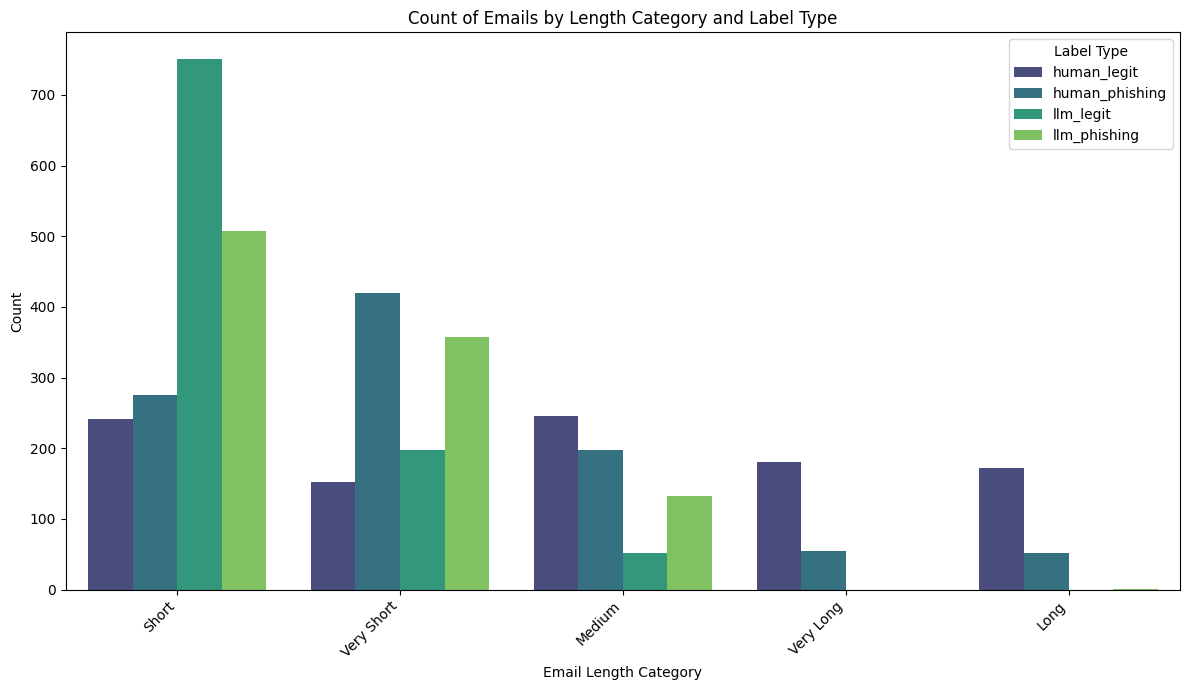

In [36]:
plt.figure(figsize=(12, 7))
sns.countplot(x='length_category', hue='label', data=raw_data, palette='viridis', order=raw_data['length_category'].value_counts().index)
plt.title('Count of Emails by Length Category and Label Type')
plt.xlabel('Email Length Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Label Type')
plt.tight_layout()
plt.show()

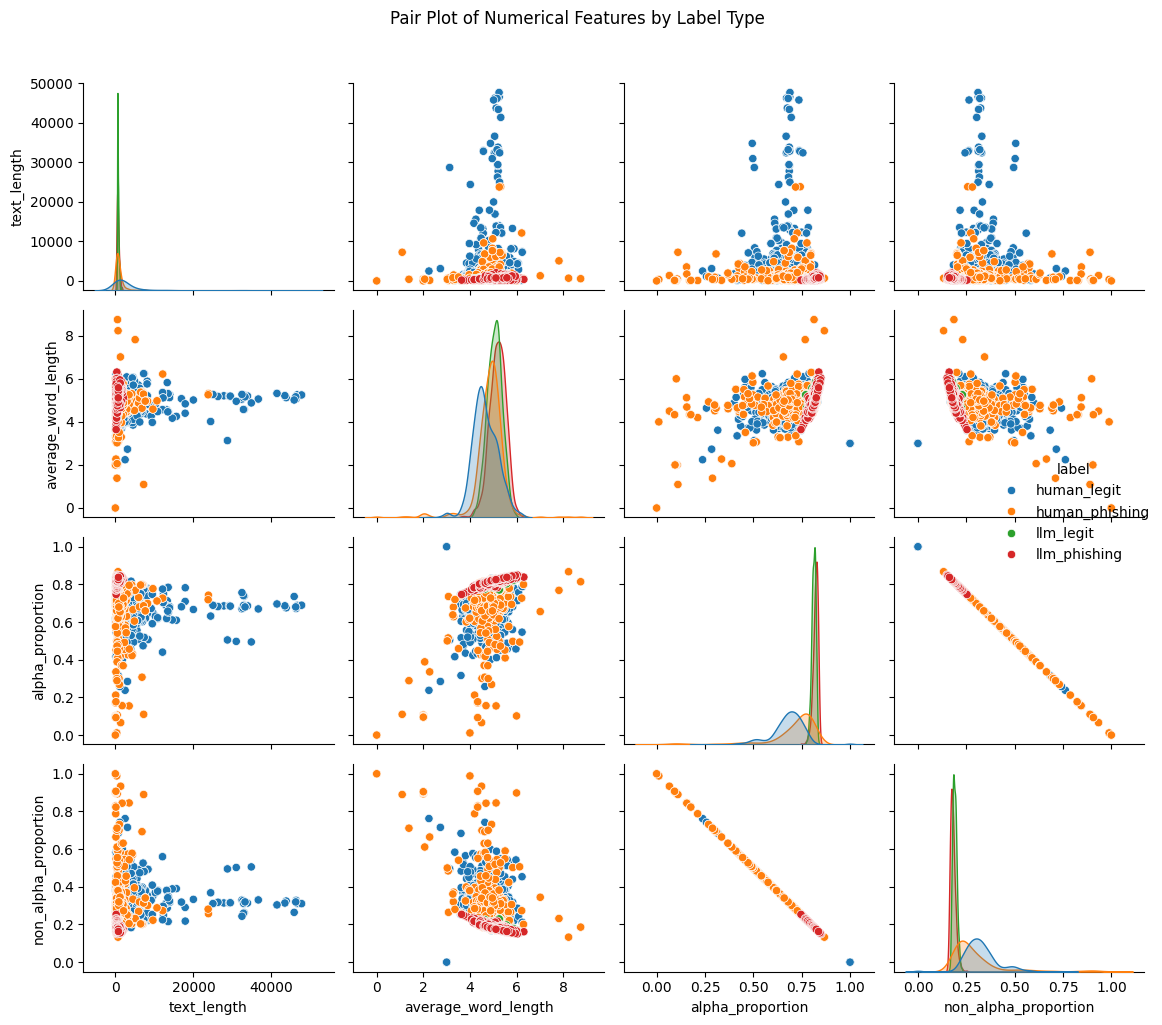

In [37]:
numerical_features = ['text_length', 'average_word_length', 'alpha_proportion', 'non_alpha_proportion']
sns.pairplot(raw_data, vars=numerical_features, hue='label', diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features by Label Type', y=1.02) # Adjust suptitle position
plt.tight_layout()
plt.show()